# MLP with hyperparameter Tuning [(medium-article)](https://medium.com/@vijaikdasari/multilayer-perceptron-and-its-hyperparameter-tuning-deedfbca2d1b)

- Grid search --> all combinations, smaller networks + limited hyperparameter ranges
- Random search --> random combinations, high-dimensional hyperparameter spaces
- Bayesian optimization --> probabilistic model that balances exploration (trying new hyperparameter combinations) and exploitation (refining around known good values), complex model + large datasets
- Automated Machine Learning (AutoML) Tools --> flexible hyperparameter search configurations, Keras Tuner / Optuna

## Import

In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
import src.utils as utils
import src.nn_core as nn
import optuna
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
from optuna.samplers import TPESampler, RandomSampler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential      # type: ignore
from tensorflow.keras.layers import Input, Dense, Dropout  # type: ignore
from tensorflow.keras.optimizers import Adam        # type: ignore

## Setup

In [132]:
# INDICATORS = [i for i in df.columns if i != 'Year']
# per ora lo faccio solo su sti tre per capire se funziona
INDICATORS = ['Livestock production index (2014-2016 = 100)']

#  'Agriculture, forestry, and fishing, value added (% of GDP)',
#  'Cereal yield (kg per hectare)'

DF_CATEGORIES = ["orig", "step_aug", "jitter_aug"]

## Upload

In [133]:
df = utils.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


## Splitting + augmentation + saving
- splitting della time serie originale in train, validation e test set,
- augmentation su train set originale (prevent data leakage) con step function e linear interpolation + jitter,
- creazione di un dizionario che contiene tutte queste cose

l'orizzonte di test è adattivo in base alla disponibilità dei dati storici di ciascun indicatore. Siccome serie sono corte ho dato priorità ad avere un punto in più nel validation set piuttosto che nel test set

============================== LIVESTOCK PRODUCTION INDEX (2014-2016 = 100) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)


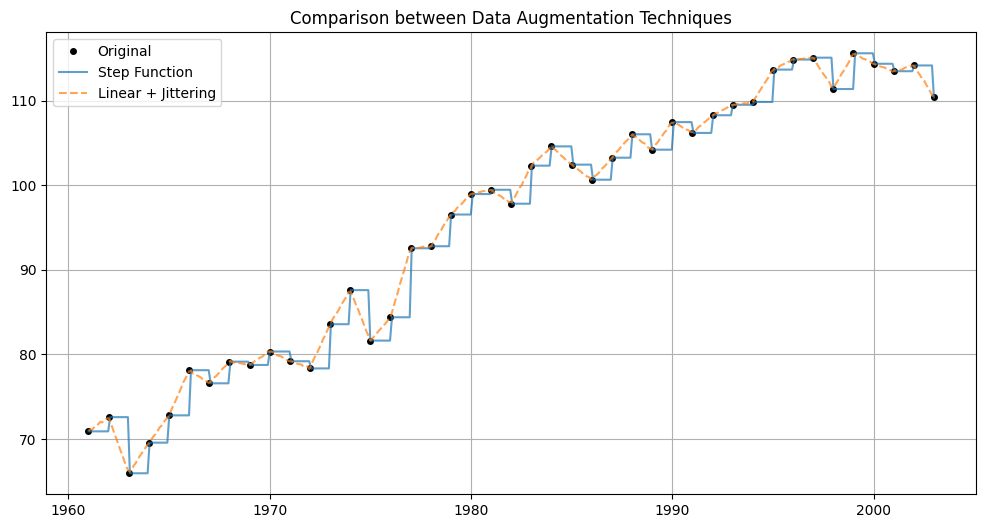

In [134]:
# dizionario per salvare in memoria i subset originali e i train aumentati con step e linear
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = nn.split_time_series(df_temp)    # splitto la time serie ORIGINALE
    
    # faccio augmentation SOLO sul train set: aumento sia anni che valori
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = nn.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = nn.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    nn.plot_augmented(df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

## Scaling
- scaling di tutto ciò che è all'interno del dizionario facendo fit su valori del train originale (diviso per anno e valore) e transform sui dataframe aumentati.

In [135]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}

for indicator in INDICATORS:
    scaled_subsets, scalers = nn.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

## Definition of search space = objective function for RandomSearch and Optuna

In [136]:
def objective(trial, scaled_data_dict):
    """
    Defines an objective function that is used in hyperparameter optimization, specifically with Optuna.
    
    Args: 
        trial = which is an Optuna Trial object used to sample hyperparameters
        scaled_data_dict = contains scaled training and validation data
        
    Returns:
        best_val_loss = minimum validation loss gotten
    """
    # iperparametri riguardanti la struttura della rete
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_int('units', 8, 64)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    
    # iperparametri riguardanti traning
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
    dropout_rate = trial.suggest_categorical('dropout', [0.1, 0.2, 0.3])
    
    # iperparametri riguardanti i dati
    n_input_steps = trial.suggest_categorical('n_input_steps', [3, 5, 10])
    
    train_data = scaled_data_dict['train'] 
    val_data = scaled_data_dict['val']
    
    X_train, y_train = nn.create_sequences(train_data['Value'], n_input_steps)
    X_val, y_val = nn.create_sequences(val_data['Value'], n_input_steps)
    
    # Check di sicurezza: se la window è troppo grande e i dati pochi, X è vuoto
    if len(X_train) == 0 or len(X_val) == 0:
        raise optuna.TrialPruned() # Abortisci questo tentativo

    # BUILD MODEL
    model = Sequential()
    
    # Input Layer
    model.add(Input(shape=(n_input_steps,)))
    model.add(Dense(units, activation=activation))
    
    # Hidden Layers
    for i in range(n_layers - 1):
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))
        
    # Output Layer
    model.add(Dense(1)) # Lineare per regressione
    
    # TRAINING
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    # Allenamento breve per valutare la bontà (es. 50 epoche)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )
    
    # RETURNS SCORE = lowest validation loss gotten
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss

In [137]:
tuning_results = []
BACKUP_FILE = "tuning_results_backup.pkl"
N_TRIALS = 10 

for SAMPLER_MODE in ["Random", "TPE"]:
    for indicator in INDICATORS:
        print(f"\n{'='*40} PROCESSING: {indicator} [{SAMPLER_MODE}] {'='*40}")
        
        for df_category in DF_CATEGORIES:
            print(f"\nOptimizing: {df_category}")
            
            data_package = {
                'train': scaled_orig_aug_subsets[indicator][f'{df_category}_train'],
                'val':   scaled_orig_aug_subsets[indicator]['orig_val']
            }
            
            if SAMPLER_MODE == "Random":
                sampler = RandomSampler(seed=42)
            else:
                sampler = TPESampler(seed=42)

            study = optuna.create_study(direction='minimize', sampler=sampler)
            try:
                study.optimize(lambda trial: objective(trial, data_package), n_trials=N_TRIALS)
            except Exception as e:
                print(f"Skipping {indicator}-{df_category}: {e}")
                continue

            result_entry = {
                "indicator": indicator,
                "sampler": SAMPLER_MODE,
                "dataset_type": df_category,
                "best_params": study.best_params,
                "best_val_loss": study.best_value
            }
            
            tuning_results.append(result_entry)
            print(f"-> Saved params for {indicator} ({df_category})")

            with open(BACKUP_FILE, "wb") as f:
                pickle.dump(tuning_results, f)

print(f"\nHo trovato i parametri ottimali per {len(tuning_results)} configurazioni.")

[I 2025-11-28 16:58:02,477] A new study created in memory with name: no-name-a91acc0a-17ac-4ad6-887e-cc36382b8495



======================================== PROCESSING: Livestock production index (2014-2016 = 100) [Random] ========================================

Optimizing: orig


[I 2025-11-28 16:58:14,871] Trial 0 finished with value: 0.00634614285081625 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.00634614285081625.
[I 2025-11-28 16:58:25,691] Trial 1 finished with value: 0.00465786037966609 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 1 with value: 0.00465786037966609.
[I 2025-11-28 16:58:25,700] Trial 2 pruned. 
[I 2025-11-28 16:58:25,705] Trial 3 pruned. 
[I 2025-11-28 16:58:25,710] Trial 4 pruned. 
[I 2025-11-28 16:58:37,289] Trial 5 finished with value: 0.004416474606841803 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 5 with value: 0.004416474606841803.


-> Saved params for Livestock production index (2014-2016 = 100) (orig)

Optimizing: step_aug


[I 2025-11-28 16:59:10,457] Trial 0 finished with value: 0.004056939855217934 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.004056939855217934.
[I 2025-11-28 16:59:23,879] Trial 1 finished with value: 0.0038465012330561876 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 1 with value: 0.0038465012330561876.
[I 2025-11-28 16:59:23,886] Trial 2 pruned. 
[I 2025-11-28 16:59:23,892] Trial 3 pruned. 
[I 2025-11-28 16:59:23,892] Trial 4 pruned. 
[I 2025-11-28 16:59:38,973] Trial 5 finished with value: 0.00377404666505754 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 5 with value: 0.003774046665057

...

-> Saved params for Livestock production index (2014-2016 = 100) (orig)

Optimizing: step_aug


[I 2025-11-28 17:02:22,777] Trial 0 finished with value: 0.003798107849434018 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.003798107849434018.
[I 2025-11-28 17:02:36,003] Trial 1 finished with value: 0.003762520384043455 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 1 with value: 0.003762520384043455.
[I 2025-11-28 17:02:36,009] Trial 2 pruned. 
[I 2025-11-28 17:02:36,009] Trial 3 pruned. 
[I 2025-11-28 17:02:36,019] Trial 4 pruned. 
[I 2025-11-28 17:02:50,416] Trial 5 finished with value: 0.0037956058513373137 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 1 with value: 0.003762520384043

-> Saved params for Livestock production index (2014-2016 = 100) (step_aug)

Optimizing: jitter_aug


[I 2025-11-28 17:03:26,517] Trial 0 finished with value: 0.003900859970599413 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.003900859970599413.
[I 2025-11-28 17:03:39,309] Trial 1 finished with value: 0.007108683232218027 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.003900859970599413.
[I 2025-11-28 17:03:39,313] Trial 2 pruned. 
[I 2025-11-28 17:03:39,320] Trial 3 pruned. 
[I 2025-11-28 17:03:39,354] Trial 4 pruned. 
[I 2025-11-28 17:03:53,861] Trial 5 finished with value: 0.004542456474155188 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.0039008599705994

-> Saved params for Livestock production index (2014-2016 = 100) (jitter_aug)

Ho trovato i parametri ottimali per 6 configurazioni.


In [138]:
predictions_dict = {}
print(f"Avvio Refitting su {len(tuning_results)} configurazioni...")

for entry in tuning_results:
    ind = entry['indicator']
    sampler = entry['sampler']
    ds_type = entry['dataset_type']
    params = entry['best_params']
    
    print(f"Refitting: {ind} | {sampler} | {ds_type} ...", end=" ")
    
    scaler_y = scalers_subsets[ind]['scaler_y']
    train_df = scaled_orig_aug_subsets[ind][f'{ds_type}_train']
    val_df   = scaled_orig_aug_subsets[ind]['orig_val']
    test_df  = scaled_orig_aug_subsets[ind]['orig_test']
    
    n_steps = params['n_input_steps']
    X_train, y_train = nn.create_sequences(train_df['Value'], n_steps)
    X_val, y_val = nn.create_sequences(val_df['Value'], n_steps)
    X_test, y_test = nn.create_sequences(test_df['Value'], n_steps)
    
    if len(X_test) == 0:
        print(f"SKIP {ind}-{ds_type}: Test set troppo corto per window {n_steps}")
        continue

    model = nn.build_mlp_model(params, input_dim=n_steps)
    history, model = nn.train_mlp_model(
        model, X_train, y_train, X_val, y_val, 
        batch_size=params['batch_size'], epochs=150, patience=15
    )
    
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_test_real = scaler_y.inverse_transform(y_test).flatten()
    
    aligned_years = test_df['Year'].values[n_steps:]
    
    assert len(aligned_years) == len(y_test_real), "Errore di allineamento anni!"

    if ind not in predictions_dict: predictions_dict[ind] = {}
    if sampler not in predictions_dict[ind]: predictions_dict[ind][sampler] = {}
    
    predictions_dict[ind][sampler][ds_type] = {
        'years': aligned_years,
        'y_true': y_test_real,
        'y_pred': y_pred_real,
        'params': params,
        'metrics': utils.evaluate_forecast(y_test_real, y_pred_real)
    }
    print("DONE")
    
print("Refitting Completato. Anni salvati correttamente.")
display(predictions_dict)

Avvio Refitting su 6 configurazioni...
Refitting: Livestock production index (2014-2016 = 100) | Random | orig ... DONE
Refitting: Livestock production index (2014-2016 = 100) | Random | step_aug ... DONE
Refitting: Livestock production index (2014-2016 = 100) | Random | jitter_aug ... DONE
Refitting: Livestock production index (2014-2016 = 100) | TPE | orig ... DONE
Refitting: Livestock production index (2014-2016 = 100) | TPE | step_aug ... DONE
Refitting: Livestock production index (2014-2016 = 100) | TPE | jitter_aug ... DONE
Refitting Completato. Anni salvati correttamente.


{'Livestock production index (2014-2016 = 100)': {'Random': {'orig': {'years': array([2019, 2020, 2021, 2022]),
    'y_true': array([107.13, 104.73, 107.33, 102.34]),
    'y_pred': array([102.01309,  99.44248, 102.51508, 105.90058], dtype=float32),
    'params': {'n_layers': 1,
     'units': 14,
     'activation': 'tanh',
     'learning_rate': 0.0004253162363790873,
     'batch_size': 16,
     'dropout': 0.2,
     'n_input_steps': 5},
    'metrics': {'RMSE': np.float64(4.7435),
     'MAE': 4.695,
     'MAPE': np.float64(4.45)}},
   'step_aug': {'years': array([2019, 2020, 2021, 2022]),
    'y_true': array([107.13, 104.73, 107.33, 102.34]),
    'y_pred': array([101.12587, 101.74907, 101.1884 , 103.56182], dtype=float32),
    'params': {'n_layers': 1,
     'units': 26,
     'activation': 'relu',
     'learning_rate': 0.0059487468132197715,
     'batch_size': 32,
     'dropout': 0.3,
     'n_input_steps': 5},
    'metrics': {'RMSE': np.float64(4.5866),
     'MAE': 4.0871,
     'MAPE': np.

In [139]:
def plot_full_history_comparison(indicator_name, predictions_dict, train_df, val_df, test_df, scaler_y):
    """
    Plotta l'intera serie storica (Train+Val+Test) e sovrappone le predizioni nel periodo di test.
    Evidenzia l'area di test in grigio.
    """
    full_scaled = pd.concat([train_df, val_df, test_df]).sort_values('Year')
    
    y_full_real = scaler_y.inverse_transform(full_scaled['Value'].values.reshape(-1, 1)).flatten()
    years_full = full_scaled['Year'].values
    
    if indicator_name not in predictions_dict:
        print(f"Skipping plot for {indicator_name}: No predictions found.")
        return
    data = predictions_dict[indicator_name]

    fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    styles = {
        'orig':       {'color': '#1f77b4', 'ls': '--', 'label': 'Pred - Orig'},
        'step_aug':   {'color': '#2ca02c', 'ls': '-.', 'label': 'Pred - Step Aug'},
        'jitter_aug': {'color': '#ff7f0e', 'ls': ':',  'label': 'Pred - Jitter Aug'}
    }
    
    test_start = int(test_df['Year'].min())
    test_end = int(test_df['Year'].max())

    for i, sampler in enumerate(['Random', 'TPE']):
        ax = axes[i]
        sampler_data = data.get(sampler, {})
        
        ax.plot(years_full, y_full_real, label='Real', marker='.', color='black', linewidth=2, alpha=0.8)
        ax.axvspan(test_start - 0.5, test_end + 0.5, color='#808080', alpha=0.2)
        
        if sampler_data:
            for ds_type, res in sampler_data.items():
                years_pred = res['years']
                y_pred = res['y_pred']
                rmse = res['metrics']['RMSE']
                
                style = styles.get(ds_type, {})
                label_txt = f"{style['label']} (RMSE: {rmse:.2f})"
                # show year ticks on this axis as well (approx 10 ticks)
                step = max(1, len(years_full) // 10)
                xticks = years_full[::step]
                ax.set_xticks(xticks)
                ax.set_xticklabels([int(x) for x in xticks])
                # ensure labels are visible even if sharex=True (top plot usually hides them)
                ax.tick_params(axis='x', which='both', labelbottom=True)
                ax.plot(years_pred, y_pred, color=style['color'], linestyle=style['ls'], linewidth=2, label=label_txt)
        
        ax.set_title(f"Hyperparameter Tuning Method: {sampler}", fontsize=14)
        ax.set_xlabel("Year")
        ax.set_ylabel("Value")
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        fig.suptitle(f'{indicator_name} - MLP predictions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

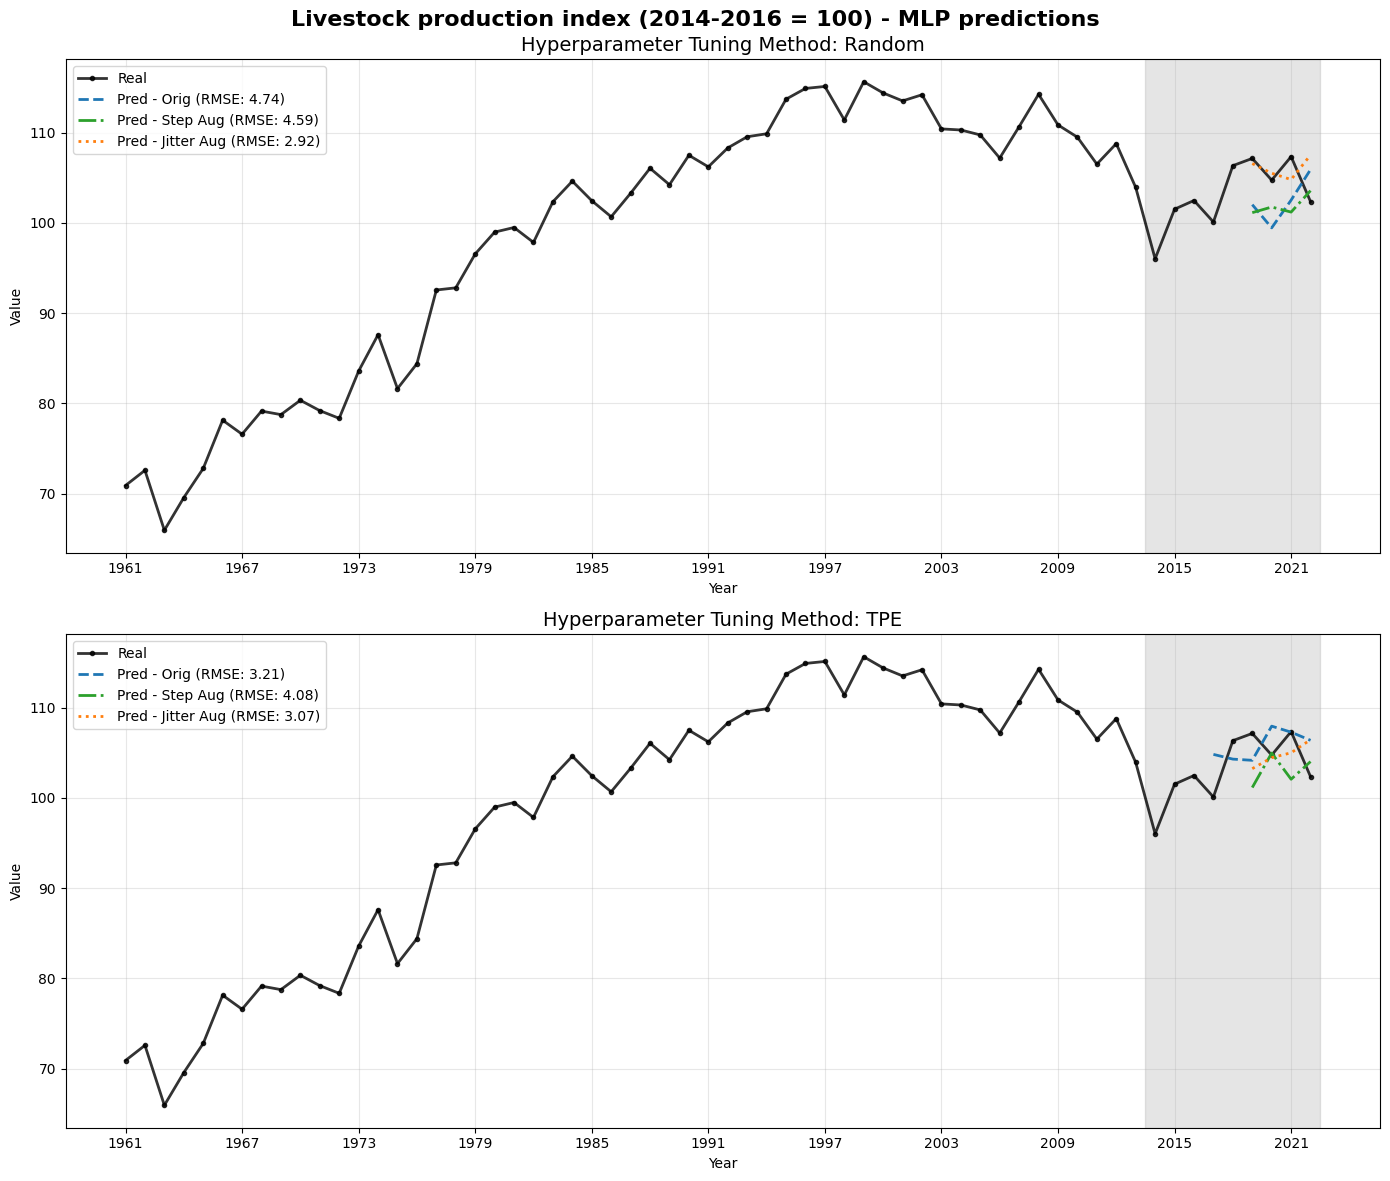

In [140]:
train_orig = scaled_orig_aug_subsets[indicator]['orig_train']
val_orig   = scaled_orig_aug_subsets[indicator]['orig_val']
test_orig  = scaled_orig_aug_subsets[indicator]['orig_test']

scaler_y = scalers_subsets[indicator]['scaler_y']

plot_full_history_comparison(
    indicator, 
    predictions_dict, 
    train_orig, 
    val_orig, 
    test_orig, 
    scaler_y
)

for ogni_indicatore in 28_indicatori:
    # 1. Ottimizza iperparametri specifici per questa serie
    best_params = hyperparameter_tuning(indicatore_data)
    
    # 2. Training del modello con parametri ottimizzati
    model = train_MLP(data, best_params)
    
    # 3. Calcola metriche
    metrics = calculate_all_metrics(test, predictions)
    
    # 4. Salva metriche con iperparametri
    append_metrics_to_excel(indicatore, 'MLP', metrics)
